## MLP: Perceptron Multicapa

En scikit-learn, un MLP (Multi-Layer Perceptron) es un tipo de red neuronal artificial que se implementa mediante las clases MLPClassifier para clasificación y MLPRegressor para regresión. Este modelo está compuesto por una capa de entrada, una o más capas ocultas y una capa de salida, donde cada neurona aplica una función de activación (como relu, tanh o logistic) para introducir no linealidad. El entrenamiento se realiza de forma iterativa mediante algoritmos como adam, sgd o lbfgs, optimizando una función de pérdida (como log-loss o MSE) para ajustar los pesos. 

En nuestro ejemplo, construimos con MLP de Sklearn un precictor del sentimiento en base a las reseñas y los ratings.   
Para ello emleamos un dataset de film affinity de películas españolas.
El objetivo es predecir en sentimiento en base al texto de las reseñas.


## 🧠 ¿Qué es un MLP y por qué usarlo aquí?

Un **Perceptrón Multicapa (MLP)** es la arquitectura de red neuronal más básica que va más allá del perceptrón simple. Se compone de:

- **Capa de entrada**: recibe las features (en este caso, el vector TF-IDF de cada reseña)
- **Capas ocultas**: aprenden representaciones intermedias no lineales gracias a las funciones de activación
- **Capa de salida**: produce la predicción final (sentimiento positivo/negativo)

**¿Por qué MLP para clasificación de texto?**
> En este notebook usamos TF-IDF para convertir texto en vectores numéricos de alta dimensión. El MLP puede aprender qué combinaciones de palabras son predictoras del sentimiento, aunque *no tiene en cuenta el orden de las palabras* (eso lo hacen las RNN/LSTM).

---
### 🎯 Objetivo del notebook
Predecir si una reseña de FilmAffinity es **positiva** (rating ≥ 7) o **negativa** (rating < 7) a partir del texto.

In [1]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords')
import numpy as np

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\tomas\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


#### 0. Importamos los datos

In [2]:
import os
os.getcwd()

'C:\\Users\\tomas\\ML\\Master Data Science and AI\\09 Deep Learning'

In [3]:
path='./data/reviews_filmaffinity.csv'
df2 = pd.read_table(path, sep='\|\|', header=0, engine='python')
df2.sample(5)

<>:2: SyntaxWarning: invalid escape sequence '\|'
<>:2: SyntaxWarning: invalid escape sequence '\|'
C:\Users\tomas\AppData\Local\Temp\ipykernel_119632\704397863.py:2: SyntaxWarning: invalid escape sequence '\|'
  df2 = pd.read_table(path, sep='\|\|', header=0, engine='python')


,film_name,gender,film_avg_rate,review_rate,review_title,review_text
7440,REC,Terror,"6,6",7.0,Existe buen cine de terror en España,Dentro de un presupuesto bajo y con un argumen...
7029,Los crímenes de Oxford,Intriga,"5,7",4.0,¿Eres tú?,Hace algún tiempo y con una testigo presencial...
2833,Campeones,Comedia,"6,9",3.0,Totalmente predecible,No voy a entrar a detallar la calidad de actua...
7212,Los crímenes de Oxford,Intriga,"5,7",6.0,Como en Flipper...,Elijah Wood tiene la misma cara y el mismo cue...
6102,La niña de tus ojos,Drama,"6,2",9.0,"Y de la Shygulla, que?","Nadie la nombra, nadie la conoce...Yo que ya p..."


#### 1. Transformamos los datos

In [4]:
nltk.download('stopwords')
spanish_stopwords = stopwords.words('spanish')
vectorizer = TfidfVectorizer(stop_words=spanish_stopwords)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\tomas\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [5]:
df2.shape

(8603, 6)

#### 1.1 Sampling
Nos quedamos con una muestra de 1000 reseñas  para que los procesos de calculo sean más ligeros

In [7]:
df3 = df2.sample(n=1000, random_state=42)
#df3=df2[df2['film_name']=='Tadeo Jones 2']
df3

,film_name,gender,film_avg_rate,review_rate,review_title,review_text
7529,REC,Terror,"6,6",7.0,"Sí, pero no...","Con tanta promoción, markéting, buenas crítica..."
8125,Los dos lados de la cama,Comedia,"5,5",3.0,¡Qué alguien me saque de esta cama!,Vale que la primera no era lo que se dice una ...
7071,Los crímenes de Oxford,Intriga,"5,7",3.0,¿Pero qué te ha pasado Alex de la Iglesia para...,¿Porqué no llamarlo “Los crímenes de la univer...
8572,La isla mínima,Cine negro,"7,2",9.0,No verla sería un delito,"Dirigida por Alberto Rodríguez (""Grupo 7""), el..."
5494,Volver,Drama,"7,1",9.0,Recomendable 100%,Es una película muy original que engancha desd...
...,...,...,...,...,...,...
4541,Tengo ganas de ti,Romance,"4,8",8.0,Pues a mí sí,He de decir que iba con unas expectativas muy ...
3779,Alatriste,Aventuras,"5,5",9.0,Un buen ejemplo a seguir para el cine español,Cualquiera puede entender que el fín de la pel...
4825,"Torrente, el brazo tonto de la ley",Comedia,"5,8",10.0,"El mas alto nivel de ""humor bajo""","En primer lugar quiero ser agresivo, muy agres..."
402,Ocho apellidos vascos,Comedia,"6,0",9.0,Una Gran Mezcla,Me gusta esta película porque hay una mezcla e...


#### 1.2 Construcción de la variable objetivo
Binarizamos la variable review rate de modo que se ies 7 ó más consideramos sentimiento positivo 

In [8]:
# Crear un binarizador con un umbral especificado
from sklearn.preprocessing import Binarizer
threshold = 7.0
binarizer = Binarizer(threshold=threshold)

# Aplicar la binarización a los datos
df3['sentiment']  = binarizer.fit_transform(df3[['review_rate']])
df3


,film_name,gender,film_avg_rate,review_rate,review_title,review_text,sentiment
7529,REC,Terror,"6,6",7.0,"Sí, pero no...","Con tanta promoción, markéting, buenas crítica...",0.0
8125,Los dos lados de la cama,Comedia,"5,5",3.0,¡Qué alguien me saque de esta cama!,Vale que la primera no era lo que se dice una ...,0.0
7071,Los crímenes de Oxford,Intriga,"5,7",3.0,¿Pero qué te ha pasado Alex de la Iglesia para...,¿Porqué no llamarlo “Los crímenes de la univer...,0.0
8572,La isla mínima,Cine negro,"7,2",9.0,No verla sería un delito,"Dirigida por Alberto Rodríguez (""Grupo 7""), el...",1.0
5494,Volver,Drama,"7,1",9.0,Recomendable 100%,Es una película muy original que engancha desd...,1.0
...,...,...,...,...,...,...,...
4541,Tengo ganas de ti,Romance,"4,8",8.0,Pues a mí sí,He de decir que iba con unas expectativas muy ...,1.0
3779,Alatriste,Aventuras,"5,5",9.0,Un buen ejemplo a seguir para el cine español,Cualquiera puede entender que el fín de la pel...,1.0
4825,"Torrente, el brazo tonto de la ley",Comedia,"5,8",10.0,"El mas alto nivel de ""humor bajo""","En primer lugar quiero ser agresivo, muy agres...",1.0
402,Ocho apellidos vascos,Comedia,"6,0",9.0,Una Gran Mezcla,Me gusta esta película porque hay una mezcla e...,1.0


#### 1.3 Vectorizamos  
Convertimos la reseña, review_tex, en un vector con TF-IDF

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer()

reviews = df3['review_text'].tolist()
tfidf_matrix3 = vectorizer.fit_transform(reviews)
tfidf_df3 = pd.DataFrame(tfidf_matrix3.toarray(), columns=vectorizer.get_feature_names_out())
tfidf_df3.head(20)

,00,000,007,01,02,03,04,10,100,1000,...,únax,única,únicamente,únicas,único,únicos,úrsula,útil,útima,útlimo
0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
1,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
2,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
3,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
4,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
5,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.085478,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
6,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
7,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
8,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.033348,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
9,0.0,0.038211,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0


### 📐 ¿Qué hace TF-IDF?

**TF-IDF** (Term Frequency - Inverse Document Frequency) convierte cada reseña en un vector numérico donde cada dimensión representa una palabra del vocabulario:

- **TF (Term Frequency)**: cuántas veces aparece una palabra en *esta* reseña
- **IDF (Inverse Document Frequency)**: penaliza palabras que aparecen en *muchas* reseñas (como "película", "film") porque aportan poco poder discriminativo

El resultado es una **matriz dispersa** donde cada fila es una reseña y cada columna es una palabra. Las celdas contienen el peso TF-IDF.

> 💡 **Intuición**: palabras como "aburrida", "magistral" o "insoportable" tendrán pesos altos porque aparecen en pocas reseñas pero son muy informativas del sentimiento.

#### 2. Modelo MLP Clasificación

#### 2.1 Entrenamos el modelo

In [10]:
# Importar las bibliotecas necesarias
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

# Datos de ejemplo (X = características, y = etiquetas de sentimiento)
# X podría ser valores numéricos extraídos de texto (TF-IDF, CountVectorizer, etc.)

X=tfidf_df3
y=df3['sentiment']

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Crear el modelo MLPClassifier
mlp = MLPClassifier(hidden_layer_sizes=(15, 10, 5), max_iter=1000, random_state=42)

# Entrenar el modelo
mlp.fit(X_train, y_train)

# Hacer predicciones en el conjunto de prueba
y_pred = mlp.predict(X_test)
y_pred_proba = mlp.predict_proba(X_test)[:, 1]
# Evaluar el modelo
accuracy = accuracy_score(y_test, y_pred)
print("Precisión del modelo:", accuracy)


Precisión del modelo: 0.735


### ✂️ División train / test

Separamos el **20% de los datos para test**, es decir, ~200 reseñas que el modelo nunca verá durante el entrenamiento. Esto nos permite evaluar cuánto generaliza el modelo a datos nuevos y detectar si hay **overfitting** (el modelo memoriza los datos de entrenamiento pero falla en test).

### 🏗️ Arquitectura del MLP

```
Entrada (TF-IDF) → 15 neuronas → 10 neuronas → 5 neuronas → 1 salida (sigmoid)
```

Los parámetros clave:
- **`hidden_layer_sizes=(15, 10, 5)`**: tres capas ocultas con 15, 10 y 5 neuronas respectivamente. Al ir reduciendo el tamaño forzamos a la red a comprimir la información.
- **`max_iter=1000`**: número máximo de épocas de entrenamiento
- **Función de activación por defecto**: `relu` — retifica los valores negativos a cero, lo que ayuda a entrenar redes profundas

> 💡 En scikit-learn el MLP usa **adam** como optimizador por defecto, que es adaptativo y converge más rápido que el SGD clásico.

#### 2.2 Evaluacion del modelo

Creamos las funciones para evaluar el modelo

### 📊 Evaluación del modelo

Para un problema de clasificación binaria (positivo/negativo), la **exactitud** (accuracy) sola no es suficiente. Si el dataset está desbalanceado (muchas más reseñas positivas que negativas), un modelo que siempre prediga "positivo" tendría alta accuracy pero sería inútil.

Usamos métricas complementarias:
- **Matriz de confusión**: muestra los verdaderos positivos, falsos positivos, verdaderos negativos y falsos negativos
- **Precision / Recall / F1**: miden la calidad de cada clase por separado
- **ROC-AUC**: mide la capacidad discriminativa del modelo independientemente del umbral

In [11]:
def confusion_matrix(y_test, predictions):
    from sklearn.metrics import confusion_matrix
    cm = confusion_matrix(y_test, predictions, labels=[1, 0])

    # Mostrar la matriz de confusión
    #print("Matriz de Confusión:")
    #print(cm)

    import seaborn as sns
    import matplotlib.pyplot as plt

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Clase 1", "Clase 0"], yticklabels=["Clase 1", "Clase 0"])
    plt.xlabel("Predicción")
    plt.ylabel("Real")
    plt.title("Matriz de Confusión")
    plt.show()
    return

def classification_report(y_test, predictions):
    from sklearn.metrics import classification_report
    report = classification_report(y_test,predictions, output_dict=True)
    # Convertir el diccionario en un DataFrame de pandas
    df_report = pd.DataFrame(report).transpose()
    print(classification_report(y_test,predictions))
    return df_report

    
def ROC_Curve (y_test, predictions):
    from sklearn.metrics import roc_auc_score
    from sklearn.metrics import roc_curve

    # Calcular ROC-AUC
    roc_auc = roc_auc_score(y_test, predictions)
    print(f"ROC-AUC: {roc_auc:.2f}")

# Calcular los valores para la curva ROC
    fpr, tpr, thresholds = roc_curve(y_test, predictions)

# Graficar la curva ROC
    plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.2f})")
    plt.plot([0, 1], [0, 1], 'k--', label="Random Guess")  # Línea diagonal para referencia
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.show()
    return roc_auc

    
def kappa_y_mcc(y_test, predictions):
    from sklearn.metrics import cohen_kappa_score, matthews_corrcoef
    # Calcular el índice Kappa
    kappa = cohen_kappa_score(y_test,predictions)
    mcc = matthews_corrcoef(y_test, predictions)
    print('kappa:' ,kappa, 'mcc:', mcc) 
    return kappa, mcc

def metricas(y_test, y_pred, y_pred_proba, tag):
    confusion_matrix(y_test, y_pred)
    df_report = classification_report(y_test, y_pred)
    roc_auc=ROC_Curve(y_test, y_pred_proba)
    kappa, mcc = kappa_y_mcc(y_test, y_pred)
    return tag, roc_auc, df_report.loc['1', 'precision'], df_report.loc['1', 'recall'], df_report.loc['1', 'f1-score'],  df_report.loc['accuracy', 'f1-score'], kappa, mcc


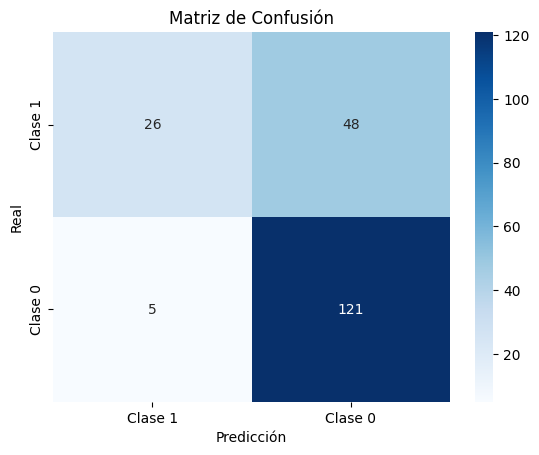

              precision    recall  f1-score   support

         0.0       0.72      0.96      0.82       126
         1.0       0.84      0.35      0.50        74

    accuracy                           0.73       200
   macro avg       0.78      0.66      0.66       200
weighted avg       0.76      0.73      0.70       200

ROC-AUC: 0.77


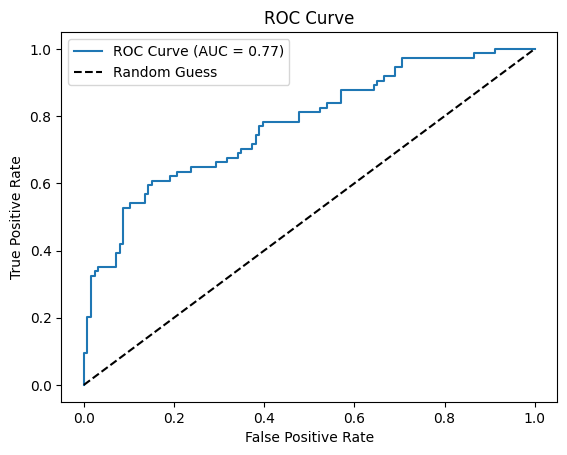

kappa: 0.35413112356812093 mcc: 0.415786398533998


(0.35413112356812093, 0.415786398533998)

In [12]:
confusion_matrix(y_test, y_pred)
classification_report(y_test, y_pred)
ROC_Curve (y_test, y_pred_proba)
kappa_y_mcc(y_test, y_pred)
#metricas(y_test, y_pred, y_pred_proba, 'MLP')

#comparador.loc[len(comparador)] = metricas(y_test, predictions, y_pred_proba, 'Decision Tree')
#comparador

In [13]:
y=mlp.predict(X)
y

array([0., 0., 0., 1., 1., 0., 0., 1., 0., 1., 1., 0., 0., 1., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 1., 0., 1., 1., 1., 0.,
       0., 0., 0., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 1.,
       0., 0., 0., 0., 0., 0., 0., 1., 0., 1., 0., 0., 1., 0., 1., 1., 0.,
       0., 0., 1., 0., 0., 0., 0., 0., 1., 0., 0., 1., 0., 0., 1., 0., 0.,
       1., 0., 0., 1., 1., 0., 0., 0., 1., 0., 1., 0., 0., 0., 0., 1., 0.,
       1., 0., 1., 0., 0., 1., 0., 0., 0., 1., 1., 0., 0., 1., 1., 0., 1.,
       0., 0., 0., 1., 0., 0., 0., 1., 0., 0., 0., 1., 0., 1., 0., 0., 0.,
       0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 1., 1.,
       0., 0., 0., 0., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 1.,
       0., 0., 1., 0., 0.

#### 2.3 Analizamos los errores del modelo

In [14]:
df3["sentiment_estim"] = y
df3

,film_name,gender,film_avg_rate,review_rate,review_title,review_text,sentiment,sentiment_estim
7529,REC,Terror,"6,6",7.0,"Sí, pero no...","Con tanta promoción, markéting, buenas crítica...",0.0,0.0
8125,Los dos lados de la cama,Comedia,"5,5",3.0,¡Qué alguien me saque de esta cama!,Vale que la primera no era lo que se dice una ...,0.0,0.0
7071,Los crímenes de Oxford,Intriga,"5,7",3.0,¿Pero qué te ha pasado Alex de la Iglesia para...,¿Porqué no llamarlo “Los crímenes de la univer...,0.0,0.0
8572,La isla mínima,Cine negro,"7,2",9.0,No verla sería un delito,"Dirigida por Alberto Rodríguez (""Grupo 7""), el...",1.0,1.0
5494,Volver,Drama,"7,1",9.0,Recomendable 100%,Es una película muy original que engancha desd...,1.0,1.0
...,...,...,...,...,...,...,...,...
4541,Tengo ganas de ti,Romance,"4,8",8.0,Pues a mí sí,He de decir que iba con unas expectativas muy ...,1.0,0.0
3779,Alatriste,Aventuras,"5,5",9.0,Un buen ejemplo a seguir para el cine español,Cualquiera puede entender que el fín de la pel...,1.0,1.0
4825,"Torrente, el brazo tonto de la ley",Comedia,"5,8",10.0,"El mas alto nivel de ""humor bajo""","En primer lugar quiero ser agresivo, muy agres...",1.0,1.0
402,Ocho apellidos vascos,Comedia,"6,0",9.0,Una Gran Mezcla,Me gusta esta película porque hay una mezcla e...,1.0,0.0


In [15]:
# Filtrar por sentiment = 1 y sentiment_estim = 0
df_filtrado = df3[(df3['sentiment'] == 1) & (df3['sentiment_estim'] == 0)]
df_filtrado.head(15)

,film_name,gender,film_avg_rate,review_rate,review_title,review_text,sentiment,sentiment_estim
3213,Torrente 3,Comedia,"3,7",9.0,Divertida y decente tercera entrega,En este mundo hay tres grupos:1: los que odian...,1.0,0.0
457,Ocho apellidos vascos,Comedia,"6,0",10.0,critica copiada pero es lo que pienso,"Genial, sencillamente genial. Mi memoria no al...",1.0,0.0
212,Ocho apellidos vascos,Comedia,"6,0",9.0,Un andaluz en las vascongadas,Después de media vida encima de los escenarios...,1.0,0.0
866,Lo imposible,Drama,"6,8",8.0,Historias que atrapan.,Mi crítica será corta pues la película no mere...,1.0,0.0
1322,El orfanato,Terror,"6,7",8.0,Única peli española que aconsejo,Pues después de leer algunas críticas de los p...,1.0,0.0
3422,Alatriste,Aventuras,"5,5",8.0,Se podría haber hecho la madre de todas las se...,Diría que se trata de una de las mejores pelíc...,1.0,0.0
4004,Celda 211,Thriller,"7,7",8.0,Increiblemente española,Recuerdo perfectamente él día que fui a ver es...,1.0,0.0
6129,Regresión,Thriller,"5,3",8.0,Perfecto thriller psicológico,"Película atmosférica y de tensión sostenida, a...",1.0,0.0
3948,Celda 211,Thriller,"7,7",8.0,"Celda 211, el mejor thriller español de la his...",De largo y con diferencia el mejor thriller qu...,1.0,0.0
1373,El orfanato,Terror,"6,7",8.0,Interesante mezcla de suspense y humor,La película me ha dejado buen sabor de boca en...,1.0,0.0


In [16]:
df3.loc[4541]['review_text']

'He de decir que iba con unas expectativas muy bajas tras Tres metros sobre el cielo. Y sin embargo, a diferencia de la primera, ésta sí me convenció. Me he leído ambos libros primero, y creo que esta vez el director Fernando González Molina sí ha acertado. Para defenderme de los maduros que opinan que esto no es más que un largometraje de la invisible camiseta de Mario Casas, diré que hay más, si se busca. Por fin aparece una mujer que sigue sus propias reglas, que hace frente al tópico del chulito, y es que Clara Lago hace una actuación tremenda. Mario Casas, frente a lo que opinan, actúa siguiendo exactamente el personaje de los libros, y María Valverde... bueno, María Valverde sale menos, y eso se agradece, no hay rabietas de niña pija a lo largo del film. Parece que hoy en día sólo se valoran las películas independientes con mensaje, o sin él, que rompen con lo establecido, y por supuesto, se lo merecen, pero también, de vez en cuando, hay que abrir un poco más las miras y disfrut

In [17]:
df3.loc[3238]['review_text']

'Creo que no me divertía tanto en una sala de cine viendo una película de animación desde "Zootrópolis" (2016) y a mi alrededor la chiquillada, mi hijo incluído, no paraba de aplaudir al final de la proyección.Hace cinco años (cómo pasa el tiempo),que se estrenó "Tadeo Jones" en estas mismas fechas y el paso del tiempo le ha sentado muy bien al personaje y al equipo técnico. Y si la primera película de las aventuras de este Indiana Jones chapuzas me gustó bastante, esta segunda parte me ha gustado todavía más. A resaltar un sobresaliente apartado técnico, una cuidada ambientación (magnífica la recreación de la Alhambra de Granada y de la calle Carrera del Darro) y un guión simple (encontrar un tesoro y rescatar a la chica) pero bien resuelto y entretenido.Y si en la primera película la clara fuente de inspiración era, como ya he dicho, Indiana Jones, en esta ocasión se nota que a los creadores de la película les encantan los videojuegos de la saga "Uncharted", de la PS4, pues Tadeo se 

#### 3. Modelo MLP Regresión

El objetivo ahora es predecir el rating a partir de las reseñas

#### 3.1 Entrenamos el modelo

In [21]:
# Importar las bibliotecas necesarias
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.metrics import accuracy_score

# Datos de ejemplo (X = características, y = etiquetas de sentimiento)
# X podría ser valores numéricos extraídos de texto (TF-IDF, CountVectorizer, etc.)

X=tfidf_df3
y=df3['review_rate']

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Crear el modelo MLPClassifier
mlp = MLPRegressor(hidden_layer_sizes=(10, 10, 5), max_iter=5000, random_state=42)

# Entrenar el modelo
mlp.fit(X_train, y_train)

# Hacer predicciones en el conjunto de prueba
y_pred = mlp.predict(X_test)

### ✂️ División train / test

Separamos el **20% de los datos para test**, es decir, ~200 reseñas que el modelo nunca verá durante el entrenamiento. Esto nos permite evaluar cuánto generaliza el modelo a datos nuevos y detectar si hay **overfitting** (el modelo memoriza los datos de entrenamiento pero falla en test).

#### 3.2 Evaluamos el modelo

In [22]:
#metricas
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
#from sklearn import metrics

# Show the values of MAE, MSE, RMSE
print('MAE:', mean_absolute_error(y_test, y_pred))
print('MSE:', mean_squared_error(y_test, y_pred))
print('RMSE:', np.sqrt(mean_squared_error(y_test, y_pred)))
print("R^2:", r2_score(y_test, y_pred))

MAE: 2.0540295478160573
MSE: 6.085093373938096
RMSE: 2.4667982029217743
R^2: 0.14395737804033315


In [20]:
y_estim=mlp.predict(X)
y_estim

array([ 6.99751806,  2.98385037,  2.97872314,  8.99014253,  8.68734492,
        6.00514129,  4.99729169,  8.00914852,  3.99375839,  8.99858922,
        7.38311988,  3.01213512,  2.99673811,  7.99562178,  7.00585683,
        3.99693232,  6.99475076,  5.99232085,  2.9958119 ,  5.99381302,
        4.00151507,  2.00622034,  5.0053904 ,  5.82840002,  6.01034499,
        4.20308589,  2.99030563,  2.9956702 ,  8.02687438,  8.00859509,
        4.26687649,  5.00670916,  5.99695575,  5.99608427,  6.00759417,
        4.98965379,  1.98268208,  4.00622695,  4.9916477 ,  5.31681188,
        6.00474129,  8.01922479,  7.01532671,  3.99158522,  4.2704551 ,
        8.97133033,  6.00976785,  9.00627522,  7.88854   ,  9.03163397,
        6.92332108,  5.99939921,  2.99938215,  6.00273578,  7.0566761 ,
        5.67568671,  9.00188972,  3.00420337,  4.99928063,  4.43938761,
        4.80982868,  6.04543908,  6.99845687,  4.84483015,  7.04304809,
        5.00644626,  5.8345816 ,  4.96473852,  2.03655928,  5.99

In [23]:
df3["rate-estim"] = y_estim
df3

,film_name,gender,film_avg_rate,review_rate,review_title,review_text,sentiment,sentiment_estim,rate-estim
7529,REC,Terror,"6,6",7.0,"Sí, pero no...","Con tanta promoción, markéting, buenas crítica...",0.0,0.0,6.997518
8125,Los dos lados de la cama,Comedia,"5,5",3.0,¡Qué alguien me saque de esta cama!,Vale que la primera no era lo que se dice una ...,0.0,0.0,2.983850
7071,Los crímenes de Oxford,Intriga,"5,7",3.0,¿Pero qué te ha pasado Alex de la Iglesia para...,¿Porqué no llamarlo “Los crímenes de la univer...,0.0,0.0,2.978723
8572,La isla mínima,Cine negro,"7,2",9.0,No verla sería un delito,"Dirigida por Alberto Rodríguez (""Grupo 7""), el...",1.0,1.0,8.990143
5494,Volver,Drama,"7,1",9.0,Recomendable 100%,Es una película muy original que engancha desd...,1.0,1.0,8.687345
...,...,...,...,...,...,...,...,...,...
4541,Tengo ganas de ti,Romance,"4,8",8.0,Pues a mí sí,He de decir que iba con unas expectativas muy ...,1.0,0.0,6.017284
3779,Alatriste,Aventuras,"5,5",9.0,Un buen ejemplo a seguir para el cine español,Cualquiera puede entender que el fín de la pel...,1.0,1.0,9.014429
4825,"Torrente, el brazo tonto de la ley",Comedia,"5,8",10.0,"El mas alto nivel de ""humor bajo""","En primer lugar quiero ser agresivo, muy agres...",1.0,1.0,10.026113
402,Ocho apellidos vascos,Comedia,"6,0",9.0,Una Gran Mezcla,Me gusta esta película porque hay una mezcla e...,1.0,0.0,4.072441


In [24]:
df_filtrado2 = df3[abs(df3['review_rate'] - df3['rate-estim']) >= 5]
df_filtrado2.head()

,film_name,gender,film_avg_rate,review_rate,review_title,review_text,sentiment,sentiment_estim,rate-estim
6129,Regresión,Thriller,"5,3",8.0,Perfecto thriller psicológico,"Película atmosférica y de tensión sostenida, a...",1.0,0.0,2.782675
2412,Mar adentro,Drama,"7,2",10.0,Una apuesta arriesgada,Pese a que muchos la consideraron la película ...,1.0,0.0,4.623642
3903,Celda 211,Thriller,"7,7",1.0,¿Habéis perdido el juicio?,"Esperaba una gran película, justo hace un año ...",0.0,0.0,6.307748
453,Ocho apellidos vascos,Comedia,"6,0",10.0,brillante,Hacía tiempo que el cine español necesitaba un...,1.0,0.0,4.402091
1452,El orfanato,Terror,"6,7",1.0,Demasiado sobrevalorada. Pero no está mal del ...,Le he puesto sólo una estrella no porque sea u...,0.0,0.0,6.012828


In [25]:

df_filtrado2.loc[1452]['review_text']

'Le he puesto sólo una estrella no porque sea una película excesivamente mala, en realidad pienso que es pasable, sino porque considero que es la película de turno que nos quieren hacer colar cada año como la gran película española que triunfa porque es buenísisma e innovadora. Vamos, que nos quieren hacer creer que es la rehostia. Y ya estoy harta.La película en si no está mal, es entretenida y asusta más o menos según el grado de predisposición de cada uno. El argumento es interesante (aunque tiene algunas cosas que no cuadran del todo) y los actores están excelentes. Sin embargo, no tiene nada que no se haya visto antes en ochocientas mil películas del género. Es una buena película pero no deja de ser una de tantas. Para mi no tiene nada que la haga especial ni que la haga destacar. Es sin más.'

#### 4. Modelo De redes neuronales para regresion con Tensor Flow

#### 4.1 Entrenamos el modelo

In [26]:
import tensorflow as tf
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Datos de ejemplo (X = características, y = variable continua)

X=tfidf_df3
y=df3['review_rate']
# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Crear el modelo con TensorFlow/Keras
model = tf.keras.Sequential([
    tf.keras.layers.Dense(10, activation='relu', input_shape=(X_train.shape[1],)),  # Primera capa oculta
    tf.keras.layers.Dense(5, activation='relu'),                                   # Segunda capa oculta
    tf.keras.layers.Dense(1)                                                      # Capa de salida (1 neurona para regresión)
])

# Compilar el modelo
model.compile(optimizer='adam', loss='mean_squared_error')

# Entrenar el modelo
model.fit(X_train, y_train, epochs=500, verbose=0)  # Entrenamiento con 500 épocas

# Hacer predicciones en el conjunto de prueba
y_pred = model.predict(X_test)

# Evaluar el modelo
mse = mean_squared_error(y_test, y_pred)
print("Error cuadrático medio:", mse)

C:\Users\tomas\ML\deep\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Error cuadrático medio: 5.84102899308249


### ✂️ División train / test

Separamos el **20% de los datos para test**, es decir, ~200 reseñas que el modelo nunca verá durante el entrenamiento. Esto nos permite evaluar cuánto generaliza el modelo a datos nuevos y detectar si hay **overfitting** (el modelo memoriza los datos de entrenamiento pero falla en test).

replico el mismo split para quiedarme solo con los datos de test 

In [27]:
print('MAE:', mean_absolute_error(y_test, y_pred))
print('MSE:', mean_squared_error(y_test, y_pred))
print('RMSE:', np.sqrt(mean_squared_error(y_test, y_pred)))
print("R^2:", r2_score(y_test, y_pred))

MAE: 2.007476096749306
MSE: 5.84102899308249
RMSE: 2.416822085525223
R^2: 0.17829202168104075


In [28]:
X_train2, X_test2, y_train, y_test = train_test_split(df3, y, test_size=0.2, random_state=42)

In [29]:
#solo muestro los resultados de test para comparar rate estim con rate review
X_test2["rate-estim_TF"] = y_pred
X_test2

,film_name,gender,film_avg_rate,review_rate,review_title,review_text,sentiment,sentiment_estim,rate-estim,rate-estim_TF
4119,Celda 211,Thriller,"7,7",9.0,Se hace lo que se puede...,"Sin duda, una de las mejores películas español...",1.0,1.0,6.746654,7.064098
5493,Volver,Drama,"7,1",7.0,Refrito de calidad.,Esta es la sensación que me dejó la película a...,0.0,0.0,4.824484,5.316891
4714,Lo dejo cuando quiera,Comedia,"5,2",7.0,El trío patético,"Remake de la película italiana del 2014 ""Smett...",0.0,0.0,4.119204,3.935898
940,Ocho apellidos catalanes,Comedia,"4,4",3.0,EL UNIVERSO DE LA ESTUPIDEZ,Lo primero que tengo que decir es que lo flipé...,0.0,0.0,4.885912,4.622900
4819,"Torrente, el brazo tonto de la ley",Comedia,"5,8",7.0,Crónica social.,"Torrente, ¿hombre o demonio? Puede que ninguna...",0.0,0.0,4.505145,4.350307
...,...,...,...,...,...,...,...,...,...,...
1595,Torrente 2: Misión en Marbella,Comedia,"5,3",5.0,MÁS CASPA Y MEJOR,Si la primera película de Torrente era casposa...,0.0,0.0,5.035419,5.208928
7149,Los crímenes de Oxford,Intriga,"5,7",7.0,Con otros actores... mejor.,"Esta película será recordada, por todo y sobre...",0.0,0.0,5.402339,5.472315
3279,Palmeras en la nieve,Drama,"6,0",3.0,NARRATIVA AJENA A LOS COMPORTAMIENTOS DE LOS A...,Una superproducción española que llega tarde. ...,0.0,0.0,5.204880,5.566207
4022,Celda 211,Thriller,"7,7",9.0,Un puto peliculón,Es la mejor película española que he visto en ...,1.0,1.0,5.877480,6.001205


In [30]:
df_filtrado3 = X_test2[abs(df3['review_rate'] - X_test2['rate-estim_TF']) >= 5]
df_filtrado3.head()

C:\Users\tomas\AppData\Local\Temp\ipykernel_119632\301698292.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_filtrado3 = X_test2[abs(df3['review_rate'] - X_test2['rate-estim_TF']) >= 5]


,film_name,gender,film_avg_rate,review_rate,review_title,review_text,sentiment,sentiment_estim,rate-estim,rate-estim_TF
2777,Torrente 4,Comedia,"4,2",10.0,deberes,"La película me he gustado, pero para mí no es ...",1.0,0.0,4.261882,4.308614
3903,Celda 211,Thriller,"7,7",1.0,¿Habéis perdido el juicio?,"Esperaba una gran película, justo hace un año ...",0.0,0.0,6.307748,6.292517
453,Ocho apellidos vascos,Comedia,"6,0",10.0,brillante,Hacía tiempo que el cine español necesitaba un...,1.0,0.0,4.402091,4.342122
1452,El orfanato,Terror,"6,7",1.0,Demasiado sobrevalorada. Pero no está mal del ...,Le he puesto sólo una estrella no porque sea u...,0.0,0.0,6.012828,6.058789


In [31]:
df_filtrado3.loc[453]['review_text']

'Hacía tiempo que el cine español necesitaba un vuelco de Estás características. Algo fresco, nuevo, claro y divertido. Real y no se tiene porqué ofender nadie, hay que ver el más allá y es que: El amor, la sensibilidad en definitiva; lo emocional, ES UNIVERSAL.'

#### 4.2 Evaluamos el modelo

In [32]:
#metricas
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
#from sklearn import metrics

# Show the values of MAE, MSE, RMSE
print('MAE:', mean_absolute_error(y_test, y_pred))
print('MSE:', mean_squared_error(y_test, y_pred))
print('RMSE:', np.sqrt(mean_squared_error(y_test, y_pred)))
print("R^2:", r2_score(y_test, y_pred))

MAE: 2.007476096749306
MSE: 5.84102899308249
RMSE: 2.416822085525223
R^2: 0.17829202168104075


#### 5 Modelo con Tensor Flow binario

In [33]:
import tensorflow as tf
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Datos de ejemplo (X = características, y = variable continua)

X=tfidf_df3
y=df3['sentiment']

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Crear el modelo con TensorFlow/Keras
model = tf.keras.Sequential([
    tf.keras.layers.Dense(10, activation='relu', input_shape=(X_train.shape[1],)),  # Primera capa oculta
    tf.keras.layers.Dense(5, activation='relu'),                                    # Segunda capa oculta
    tf.keras.layers.Dense(1, activation='sigmoid')                                  # Capa de salida para clasificación binaria
])

# Compilación del modelo
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])


# Entrenar el modelo
model.fit(X_train, y_train, epochs=500, verbose=0)  # Entrenamiento con 500 épocas




C:\Users\tomas\ML\deep\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### ✂️ División train / test

Separamos el **20% de los datos para test**, es decir, ~200 reseñas que el modelo nunca verá durante el entrenamiento. Esto nos permite evaluar cuánto generaliza el modelo a datos nuevos y detectar si hay **overfitting** (el modelo memoriza los datos de entrenamiento pero falla en test).

In [34]:
# Hacer predicciones en el conjunto de prueba
y_pred_proba = model.predict(X_test)  # Probabilidades entre 0 y 1
y_pred = (y_pred_proba > 0.5).astype(int)  # Convertir a clases 0 o 1

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


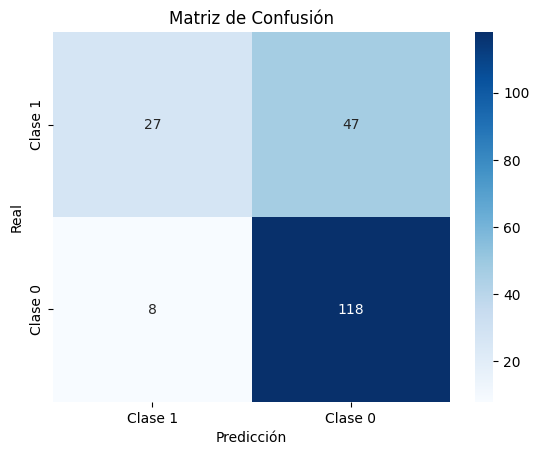

              precision    recall  f1-score   support

         0.0       0.72      0.94      0.81       126
         1.0       0.77      0.36      0.50        74

    accuracy                           0.72       200
   macro avg       0.74      0.65      0.65       200
weighted avg       0.74      0.72      0.69       200

ROC-AUC: 0.78


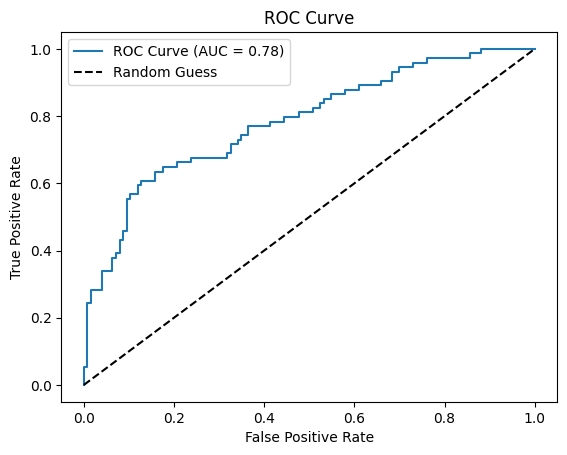

kappa: 0.33814681107099875 mcc: 0.38293864232388575


(0.33814681107099875, 0.38293864232388575)

In [35]:
confusion_matrix(y_test, y_pred)
classification_report(y_test, y_pred)
ROC_Curve (y_test, y_pred_proba)
kappa_y_mcc(y_test, y_pred)

---
## ⚙️ Parte 3: Optimización de hiperparámetros con Optuna

Hasta ahora hemos elegido los hiperparámetros manualmente (número de neuronas, learning rate, batch size...). **Optuna** automatiza este proceso mediante búsqueda bayesiana:

1. Define un espacio de búsqueda (rangos para cada hiperparámetro)
2. Entrena el modelo con una combinación concreta
3. Evalúa el resultado
4. Usa lo aprendido para elegir la siguiente combinación más prometedora

> Esto es mucho más eficiente que un **grid search** exhaustivo, especialmente cuando el espacio de hiperparámetros es grande.

In [36]:
def objective(trial, X, y):
    # Hiperparámetros
    n_units = trial.suggest_int('n_units', 8, 64)
    lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    optimizer_name = trial.suggest_categorical('optimizer', ['adam', 'rmsprop'])
    batch_size = trial.suggest_categorical('batch_size', [16, 32])
    epochs = trial.suggest_int('epochs', 10, 30)

    # Modelo
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(n_units, activation='relu', input_shape=(X.shape[1],)),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr) if optimizer_name == 'adam' else tf.keras.optimizers.RMSprop(learning_rate=lr)
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

    # Entrenamiento
    history = model.fit(X, y, validation_split=0.2, batch_size=batch_size, epochs=epochs, verbose=0)
    return max(history.history['val_accuracy'])



In [35]:
pip install optuna

  Using cached colorlog-6.9.0-py3-none-any.whl.metadata (10 kB)
  Using cached mako-1.3.10-py3-none-any.whl.metadata (2.9 kB)
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 2.1/2.1 MB 60.1 MB/s eta 0:00:00
Using cached colorlog-6.9.0-py3-none-any.whl (11 kB)
Using cached mako-1.3.10-py3-none-any.whl (78 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.2
[notice] To update, run: C:\Users\tomas\ML\deep\Scripts\python.exe -m pip install --upgrade pip


In [37]:
import optuna

C:\Users\tomas\ML\deep\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [38]:
study = optuna.create_study(direction='maximize')
study.optimize(lambda trial: objective(trial, X_train, y_train), n_trials=30)


[I 2026-01-12 05:49:37,919] A new study created in memory with name: no-name-37c3cd1d-5f42-4bfc-9385-f5ea085497d5
C:\Users\tomas\ML\deep\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
[I 2026-01-12 05:49:43,948] Trial 0 finished with value: 0.637499988079071 and parameters: {'n_units': 64, 'lr': 0.00013817644322862196, 'optimizer': 'adam', 'batch_size': 32, 'epochs': 12}. Best is trial 0 with value: 0.637499988079071.
C:\Users\tomas\ML\deep\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regular

In [47]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import RMSprop

In [48]:
best_params = study.best_params
final_model = Sequential([
    Dense(best_params['n_units'], activation='relu', input_shape=(X_train.shape[1],)),
    Dense(1, activation='sigmoid')
])

final_optimizer = Adam(learning_rate=best_params['lr']) if best_params['optimizer'] == 'adam' else RMSprop(learning_rate=best_params['lr'])

final_model.compile(optimizer=final_optimizer, loss='binary_crossentropy', metrics=['accuracy'])

final_model.fit(X_train, y_train,
                batch_size=best_params['batch_size'],
                epochs=best_params['epochs'],
                verbose=1)

Epoch 1/16
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6563 - loss: 0.6208   
Epoch 2/16
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7222 - loss: 0.4417 
Epoch 3/16
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9616 - loss: 0.2364 
Epoch 4/16
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9949 - loss: 0.1003 
Epoch 5/16
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0.0374 
Epoch 6/16
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0.0176 
Epoch 7/16
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0.0081 
Epoch 8/16
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0041 
Epoch 9/16
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0023 
Epoch 10/16
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0013 
Epoch 11/16
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 7.9837e-04 
Epoch 12/16
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accu

In [49]:
y_pred_proba = final_model.predict(X_test)
y_pred = (y_pred_proba > 0.5).astype(int)

from sklearn.metrics import accuracy_score
print("Accuracy en test:", accuracy_score(y_test, y_pred))


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Accuracy en test: 0.73


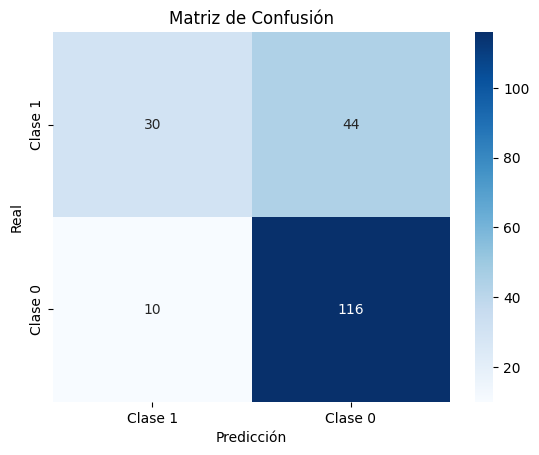

              precision    recall  f1-score   support

         0.0       0.72      0.92      0.81       126
         1.0       0.75      0.41      0.53        74

    accuracy                           0.73       200
   macro avg       0.74      0.66      0.67       200
weighted avg       0.73      0.73      0.71       200

ROC-AUC: 0.79


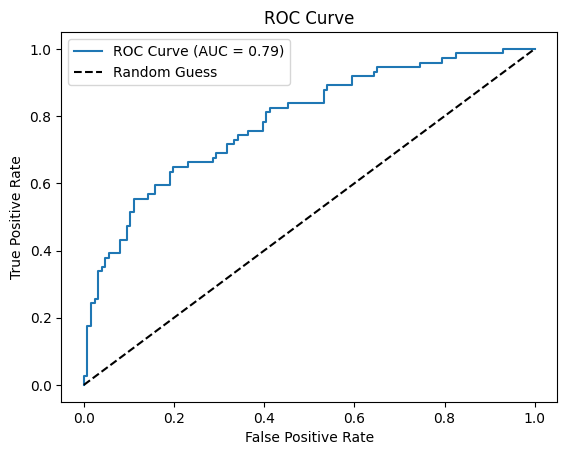

kappa: 0.3601895734597157 mcc: 0.39353418513409333


(0.3601895734597157, 0.39353418513409333)

In [50]:
confusion_matrix(y_test, y_pred)
classification_report(y_test, y_pred)
ROC_Curve (y_test, y_pred_proba)
kappa_y_mcc(y_test, y_pred)